In [1]:
# --- 1. Download the dataset ---
import kagglehub
dataset_dir = kagglehub.dataset_download("abdulhasibuddin/uc-merced-land-use-dataset")

Using Colab cache for faster access to the 'uc-merced-land-use-dataset' dataset.


Dataset root: /kaggle/input/uc-merced-land-use-dataset/UCMerced_LandUse/Images
Found classes: ['agricultural', 'airplane', 'baseballdiamond', 'beach', 'buildings', 'chaparral', 'denseresidential', 'forest', 'freeway', 'golfcourse', 'harbor', 'intersection', 'mediumresidential', 'mobilehomepark', 'overpass', 'parkinglot', 'river', 'runway', 'sparseresidential', 'storagetanks', 'tenniscourt']
Total images loaded: 2100
Training set distribution: Counter({'sparseresidential': 80, 'tenniscourt': 80, 'harbor': 80, 'chaparral': 80, 'mobilehomepark': 80, 'runway': 80, 'agricultural': 80, 'golfcourse': 80, 'beach': 80, 'buildings': 80, 'freeway': 80, 'river': 80, 'baseballdiamond': 80, 'mediumresidential': 80, 'denseresidential': 80, 'intersection': 80, 'parkinglot': 80, 'airplane': 80, 'overpass': 80, 'forest': 80, 'storagetanks': 80})
Test set distribution: Counter({'storagetanks': 20, 'sparseresidential': 20, 'tenniscourt': 20, 'airplane': 20, 'beach': 20, 'mediumresidential': 20, 'buildings

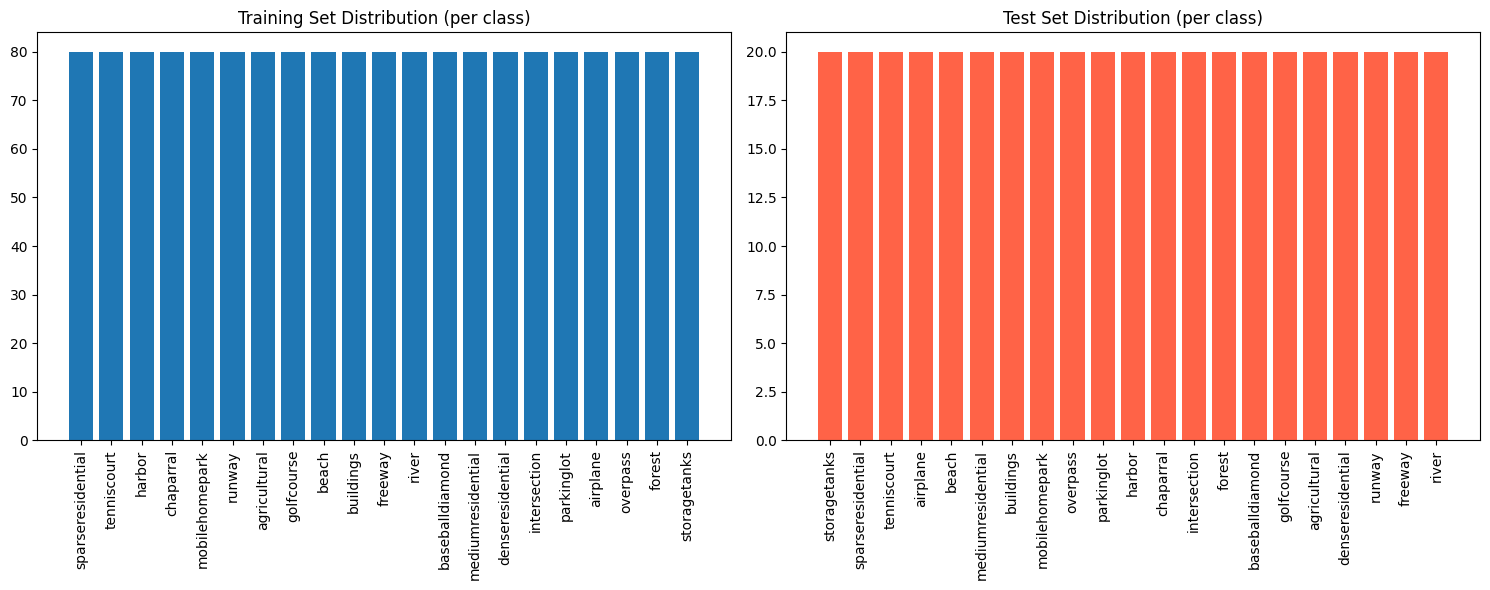

In [2]:


import os
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# --- 2. Fix dataset path for UCMerced_LandUse ---

def find_ucmerced_root(path):
    """Find the folder that contains the 21 scene classes."""
    for root, dirs, files in os.walk(path):
        # UC Merced classes all have 100 images
        if len(dirs) == 21:
            return root
    return path

dataset_dir = find_ucmerced_root(dataset_dir)
print("Dataset root:", dataset_dir)

# --- 3. Collect all image paths + labels ---
data = []

classes = sorted([
    d for d in os.listdir(dataset_dir)
    if os.path.isdir(os.path.join(dataset_dir, d))
])

print("Found classes:", classes)

for cls in classes:
    cls_path = os.path.join(dataset_dir, cls)
    for img_file in os.listdir(cls_path):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png', '.tif')):
            data.append((os.path.join(cls_path, img_file), cls))

print("Total images loaded:", len(data))

# --- 4. Split (80% train, 20% test) ---
labels = [label for _, label in data]

train_data, test_data = train_test_split(
    data,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

# --- 5. Count per class ---
train_counter = Counter([label for _, label in train_data])
test_counter = Counter([label for _, label in test_data])

print("Training set distribution:", train_counter)
print("Test set distribution:", test_counter)

# --- 6. Plot ---
plt.figure(figsize=(15, 6))

# Train histogram
plt.subplot(1, 2, 1)
plt.bar(train_counter.keys(), train_counter.values())
plt.title("Training Set Distribution (per class)")
plt.xticks(rotation=90)

# Test histogram
plt.subplot(1, 2, 2)
plt.bar(test_counter.keys(), test_counter.values(), color='tomato')
plt.title("Test Set Distribution (per class)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


In [3]:
import torch
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader

# ---------------------------------------------------------------------
# 1. CLEAN DATASET (NO AUGMENTATION)
# ---------------------------------------------------------------------

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

clean_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])


class CleanLandUseDataset(Dataset):
    """NO augmentation. Only resize + normalize."""
    def __init__(self, data):
        self.data = data
        self.transform = clean_transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        img = Image.open(img_path).convert("RGB")
        return self.transform(img), label


# ---------------------------------------------------------------------
# 2. EXPANDED 6× DATASET (FIXED AUGMENTATIONS)
# ---------------------------------------------------------------------

base_resize = transforms.Resize((299, 299))

aug_transforms = [
    transforms.Compose([base_resize]),                                  # 1. original
    transforms.Compose([base_resize, transforms.RandomRotation((90, 90))]),   # 2. rotate 90
    transforms.Compose([base_resize, transforms.RandomRotation((180, 180))]), # 3. rotate 180
    transforms.Compose([base_resize, transforms.RandomVerticalFlip(p=1.0)]),  # 4. vertical flip
    transforms.Compose([base_resize, transforms.RandomHorizontalFlip(p=1.0)]),# 5. horizontal flip
    transforms.Compose([
        transforms.Resize((360, 360)),
        transforms.RandomCrop(299)                                       # 6. zoom crop
    ])
]

normalize = transforms.Normalize(mean=imagenet_mean, std=imagenet_std)

class ExpandedLandUseDataset(Dataset):
    """Each original image returns 6 fixed augmented images."""
    def __init__(self, data):
        self.data = data
        self.num_aug = 6
        self.total_len = len(data) * self.num_aug

    def __len__(self):
        return self.total_len

    def __getitem__(self, idx):
        img_index = idx // self.num_aug
        aug_index = idx % self.num_aug

        img_path, label = self.data[img_index]
        img = Image.open(img_path).convert("RGB")

        # Apply one of the 6 transforms
        img = aug_transforms[aug_index](img)

        # To tensor + normalize
        img = transforms.ToTensor()(img)
        img = normalize(img)

        return img, label


# ---------------------------------------------------------------------
# 3. DATASETS & LOADERS
# ---------------------------------------------------------------------

batch_size = 200

train_dataset_clean = CleanLandUseDataset(train_data)
train_dataset_aug6  = ExpandedLandUseDataset(train_data)
test_dataset = CleanLandUseDataset(test_data)

train_loader_clean =  DataLoader(
    train_dataset_clean,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)


train_loader_aug6 = DataLoader(
    train_dataset_aug6,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

# ---------------------------------------------------------------------
# Print dataset sizes
# ---------------------------------------------------------------------
print("Original training images:", len(train_data))
print("Clean dataset images   :", len(train_dataset_clean))
print("Augmented 6× dataset   :", len(train_dataset_aug6))


Original training images: 1680
Clean dataset images   : 1680
Augmented 6× dataset   : 10080


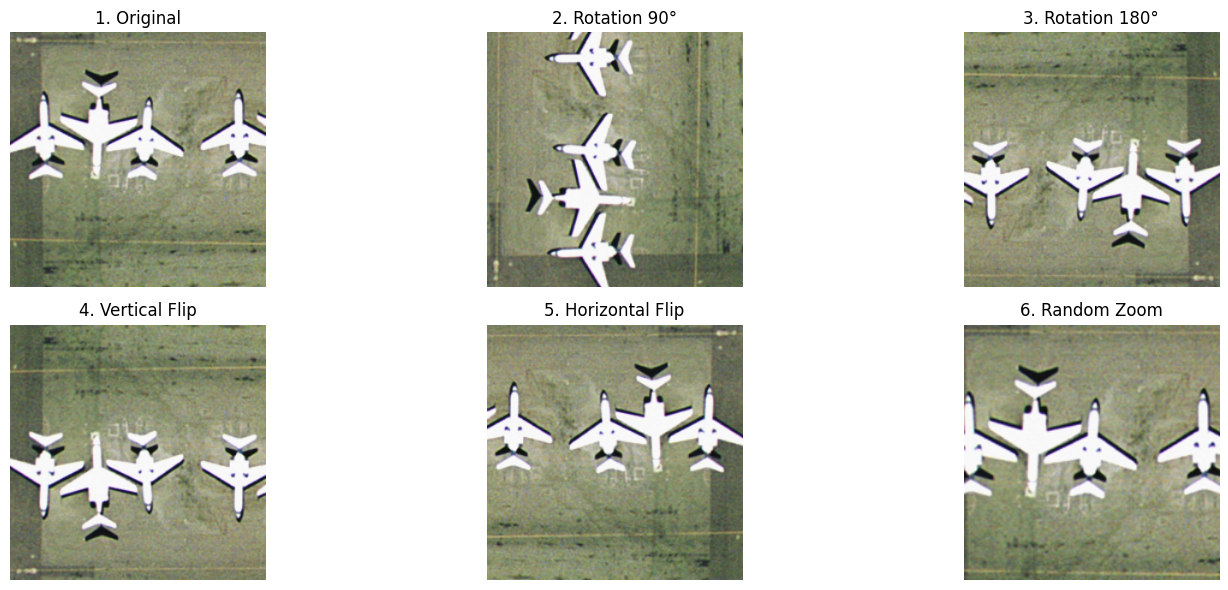

In [4]:
import random
import matplotlib.pyplot as plt
from PIL import Image

# --- 1. Find airplane images in training data ---
airplane_images = [img_path for img_path, label in train_data if label == 'airplane']
# Set seed manually
random.seed(42)
# Pick a random image path
sample_img_path = random.choice(airplane_images)
# Open the image
original_img = Image.open(sample_img_path).convert('RGB')



titles = [
    "1. Original",
    "2. Rotation 90°",
    "3. Rotation 180°",
    "4. Vertical Flip",
    "5. Horizontal Flip",
    "6. Random Zoom"
]

# --- 3. Transform images for display ---
augmented_images = [aug(original_img) for aug in aug_transforms]

# --- 4. Display ---
plt.figure(figsize=(16, 6))
for i, (img, title) in enumerate(zip(augmented_images, titles)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


# --------------------------------------------------------
# DEVICE
# --------------------------------------------------------
def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


# --------------------------------------------------------
# BUILD FAST LABEL MAP (MUCH FASTER THAN classes.index)
# --------------------------------------------------------
def build_label_map(classes):
    return {c: i for i, c in enumerate(classes)}


# --------------------------------------------------------
# TRAIN ONE EPOCH
# --------------------------------------------------------
def train_one_epoch(model, train_loader, optimizer, criterion, device, label_map):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)

        # FAST conversion using dict
        labels = torch.tensor([label_map[l] for l in labels],
                              device=device, dtype=torch.long)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)

        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total * 100


# --------------------------------------------------------
# EVALUATE (TEST)
# --------------------------------------------------------
def evaluate(model, test_loader, criterion, device, label_map):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            labels = torch.tensor([label_map[l] for l in labels],
                                  device=device, dtype=torch.long)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)

            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total * 100


# --------------------------------------------------------
# TRAIN LOOP
# --------------------------------------------------------
def train_model(model, train_loader, test_loader, classes,
                epochs=2, lr=0.01, label_smoothing=0.1,
                optimizer_type="adagrad"):

    device = get_device()
    model = model.to(device)

    # Precompute label map (massive speedup)
    label_map = build_label_map(classes)

    # -----------------------------------------
    # SELECT OPTIMIZER
    # -----------------------------------------
    if optimizer_type.lower() == "adagrad":
        optimizer = optim.Adagrad(
            filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    elif optimizer_type.lower() == "adam":
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    else:
        raise ValueError("optimizer_type must be 'adagrad' or 'adam'")

    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    train_losses, train_accs = [], []
    test_losses, test_accs = [], []

    for epoch in range(epochs):

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device, label_map)

        test_loss, test_acc = evaluate(
            model, test_loader, criterion, device, label_map)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_losses.append(test_loss)
        test_accs.append(test_acc)

    return train_losses, train_accs, test_losses, test_accs, model


# --------------------------------------------------------
# PLOT CURVES
# --------------------------------------------------------
def plot_curves(train_losses, test_losses, train_accs, test_accs):
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.title("Loss Curve")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(test_accs, label='Test Accuracy')
    plt.title("Accuracy Curve")
    plt.legend()

    plt.show()


# --------------------------------------------------------
# CONFUSION MATRIX REPORT
# --------------------------------------------------------
def show_confusion_matrix(model, test_loader, classes):
    device = next(model.parameters()).device
    model.eval()

    label_map = build_label_map(classes)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            numeric_labels = torch.tensor([label_map[l] for l in labels],
                                          device=device)

            outputs = model(images)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(numeric_labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(12,10))
    sns.heatmap(cm, annot=True, cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds))


In [7]:
xception = timm.create_model(
    "legacy_xception",
    pretrained=True,
    num_classes=0,        # no classifier
    global_pool='avg'     # automatically applies GAP
)



xception.classifier = nn.Identity()

for p in xception.parameters():
    p.requires_grad = False


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth


In [8]:

num_classes = 21
INPUT_FEATURE_SIZE = 2048

# --- Sequential Classifier Module ---
import torch
import torch.nn as nn
import torch.nn.functional as F

num_classes = 21
INPUT_FEATURE_SIZE = 2048

class FeatureNormalizer(nn.Module):
    """Implements paper formula: normalized = (x - mean) / sqrt(var + eps)"""
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, x):
        mu = x.mean(dim=1, keepdim=True)
        var = x.var(dim=1, unbiased=False, keepdim=True)
        x_norm = (x - mu) / torch.sqrt(var + self.eps)
        return x_norm


class SequentialClassifier(nn.Module):
    def __init__(self, feature_extractor, num_classes=21):
        super().__init__()

        self.features = feature_extractor

        # ---- EXACT ARCHITECTURE OF THE PAPER ----
        self.normalization = FeatureNormalizer()   # (1) Normalization layer
        self.sigmoid = nn.Sigmoid()                # (2) Sigmoid layer
        self.dropout = nn.Dropout(0.4)             # (3) Dropout layer

        # (4) Final classifier (softmax will be applied in loss)
        self.fc = nn.Linear(INPUT_FEATURE_SIZE, num_classes)

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)   # (batch , 2048)

        # --- MATCH THE PAPER PIPELINE ---
        x = self.normalization(x)  # (1) normalize
        x = self.sigmoid(x)        # (2) sigmoid
        x = self.dropout(x)        # (3) dropout
        x = self.fc(x)             # (4) classifier output (logits)

        return x   # softmax applied in loss






## 1-3 , 1-4


Running: Adagrad lr=0.01 smooth .1

Running: Adagrad lr=0.005 smooth .05

                  FINAL (LAST EPOCH) METRICS

🔷 Adagrad lr=0.01 smooth .1
   Final Train Accuracy : 92.02%
   Final Test Accuracy  : 90.71%
   Final Train Loss     : 0.9290
   Final Test Loss      : 0.9221

🔷 Adagrad lr=0.005 smooth .05
   Final Train Accuracy : 90.51%
   Final Test Accuracy  : 91.43%
   Final Train Loss     : 0.7121
   Final Test Loss      : 0.6886

 ⭐ MODEL SELECTED (Highest Final Test Accuracy): Adagrad lr=0.005 smooth .05
 ⭐ Final Test Accuracy: 91.43%



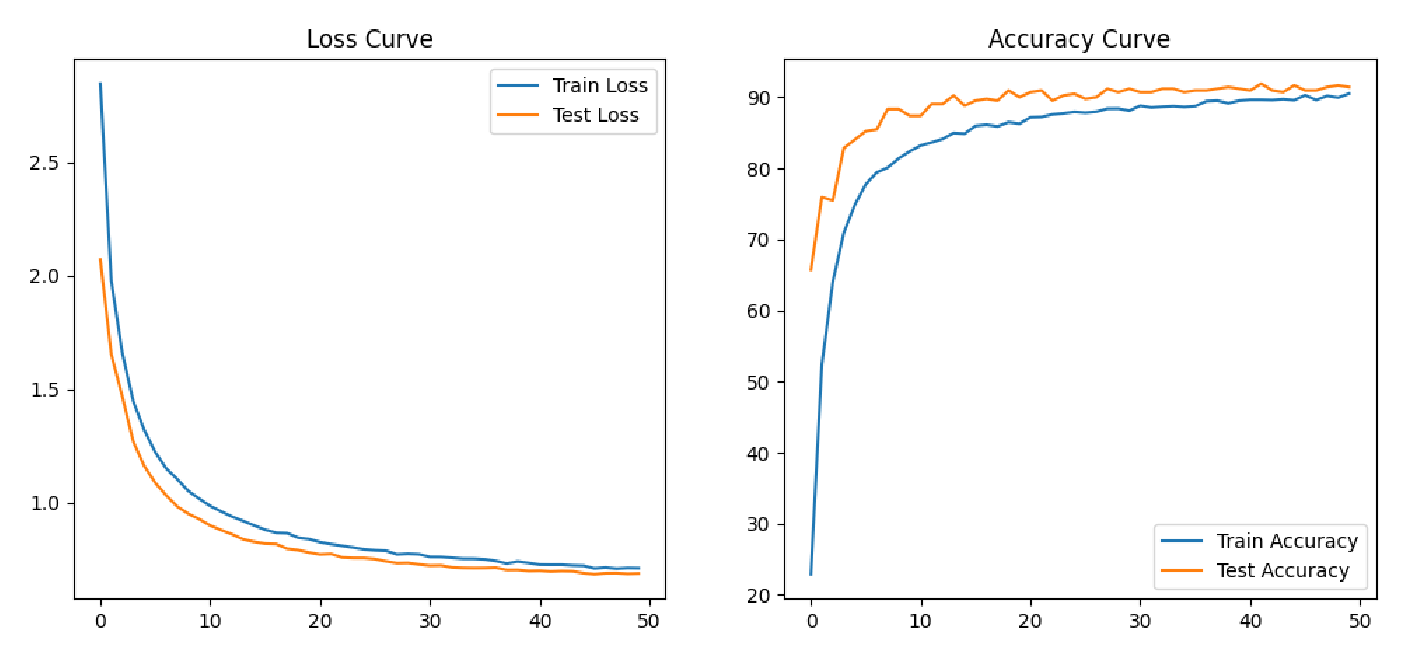

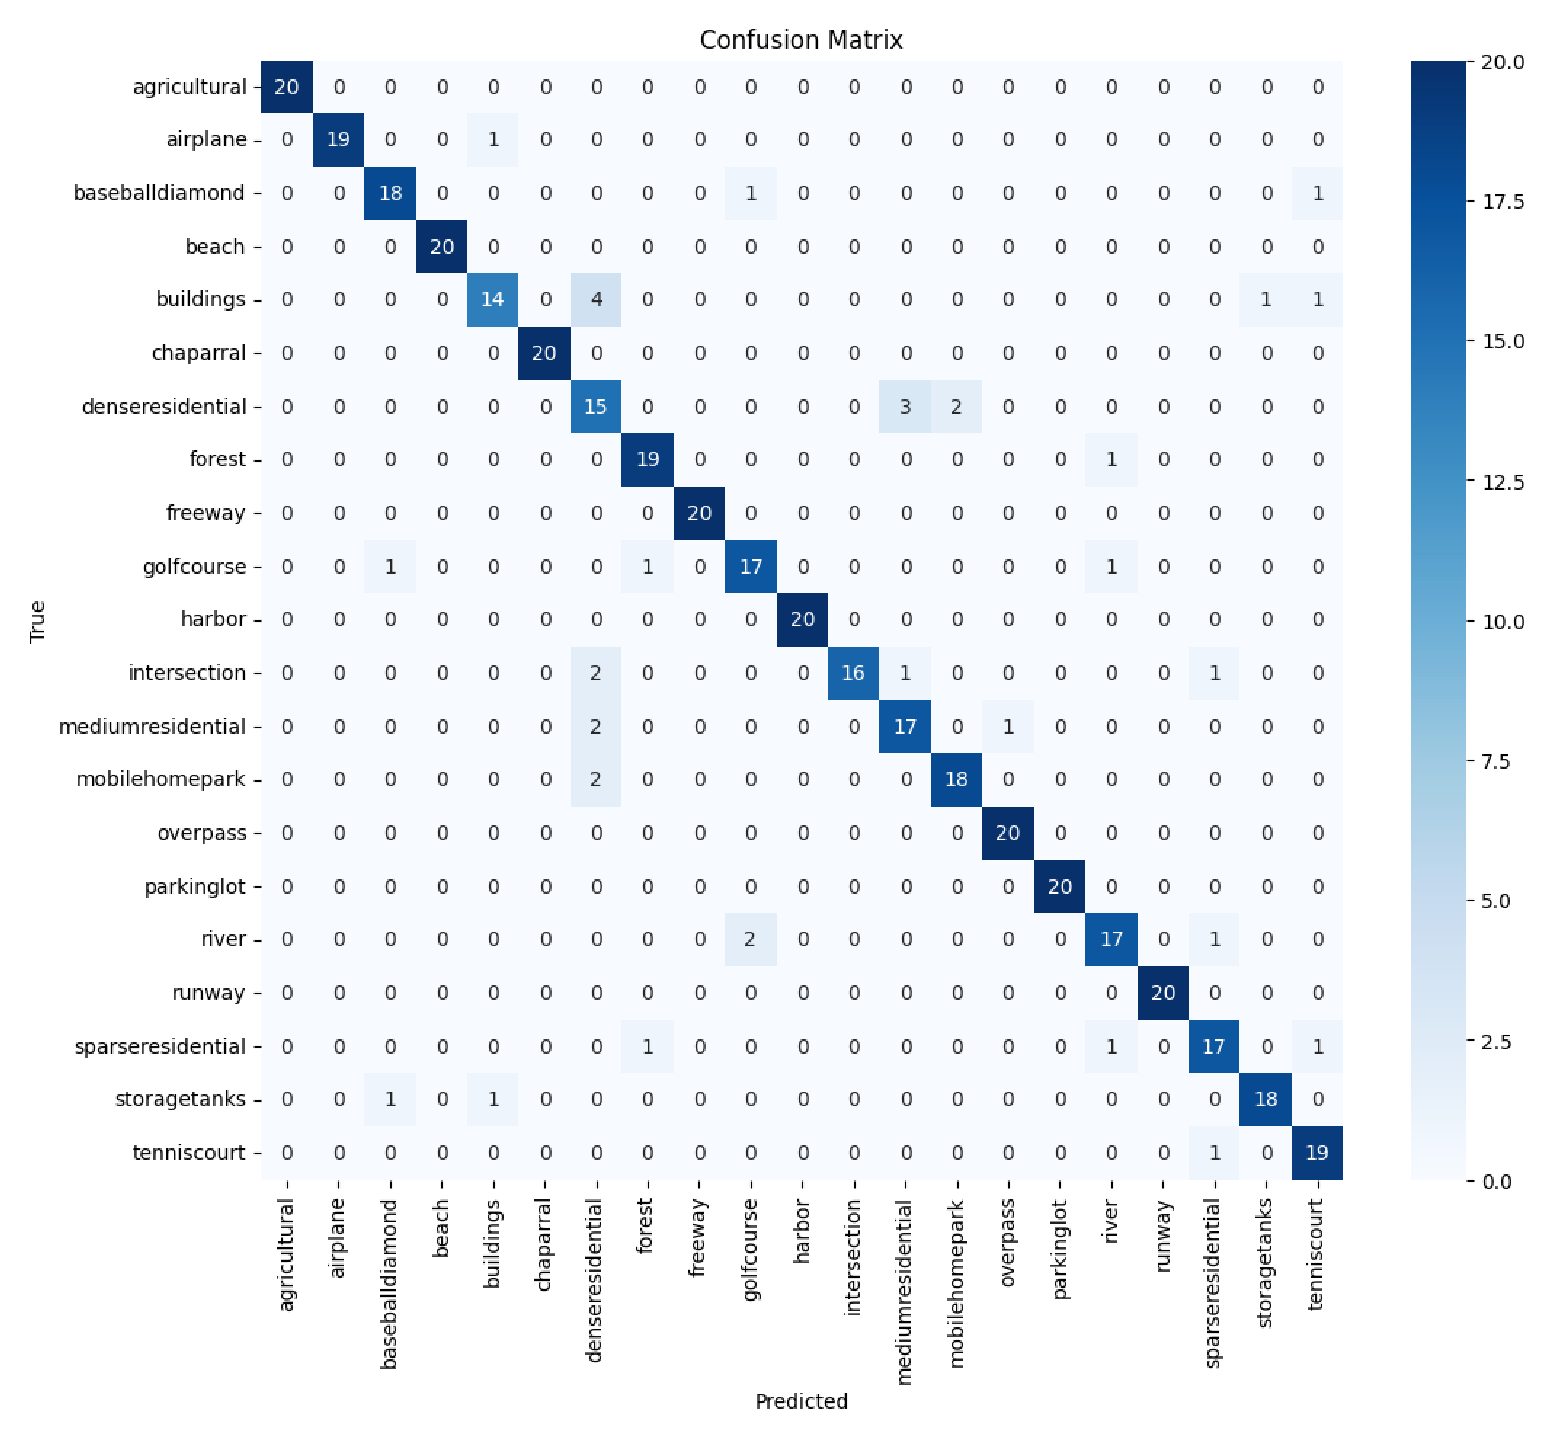


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       0.89      0.85      0.87        20
           3       1.00      1.00      1.00        20
           4       0.94      0.75      0.83        20
           5       1.00      1.00      1.00        20
           6       0.62      0.80      0.70        20
           7       1.00      1.00      1.00        20
           8       0.91      1.00      0.95        20
           9       0.86      0.95      0.90        20
          10       1.00      1.00      1.00        20
          11       1.00      0.85      0.92        20
          12       0.74      0.85      0.79        20
          13       0.95      0.90      0.92        20
          14       1.00      0.90      0.95        20
          15       1.00      1.00      1.00        20
          16       0.95      0.90      0.92        20
   

In [ ]:
# ============================================================
#               RUN 3 EXPERIMENTS & SELECT BEST MODEL
# ============================================================

experiments = [
    {"name": "Adagrad lr=0.01 smooth .1",        "epochs": 50, "lr": 0.01,  "label_smoothing": 0.1,  "optimizer_type": "adagrad"},
    {"name": "Adagrad lr=0.005 smooth .05",          "epochs": 50, "lr": 0.005, "label_smoothing": 0.05,  "optimizer_type": "adagrad"},
]

results = []



for exp in experiments:
    print(f"\nRunning: {exp['name']}")

    # Fresh model
    current_model = SequentialClassifier(
        feature_extractor=xception,
        num_classes=len(classes)
    )

    # Train (silent)
    train_losses, train_accs, test_losses, test_accs, trained_model = train_model(
        current_model,
        train_loader_aug6,
        test_loader,
        classes,
        epochs=exp["epochs"],
        lr=exp["lr"],
        label_smoothing=exp["label_smoothing"],
        optimizer_type=exp["optimizer_type"]
    )

    # Store final epoch metrics ONLY
    results.append({
        "name": exp["name"],
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_accs": train_accs,
        "test_accs": test_accs,
        "model": trained_model,
        "final_train_acc": train_accs[-1],
        "final_test_acc": test_accs[-1],
        "final_train_loss": train_losses[-1],
        "final_test_loss": test_losses[-1],
    })


# ============================================================
#               PRINT FINAL METRICS OF ALL MODELS
# ============================================================

print("\n" + "="*80)
print("                  FINAL (LAST EPOCH) METRICS")
print("="*80)

for r in results:
    print(f"\n🔷 {r['name']}")
    print(f"   Final Train Accuracy : {r['final_train_acc']:.2f}%")
    print(f"   Final Test Accuracy  : {r['final_test_acc']:.2f}%")
    print(f"   Final Train Loss     : {r['final_train_loss']:.4f}")
    print(f"   Final Test Loss      : {r['final_test_loss']:.4f}")


# ============================================================
#         CHOOSE MODEL WITH HIGHEST FINAL TEST ACCURACY
# ============================================================

best_run = max(results, key=lambda r: r["final_test_acc"])

print("\n" + "="*80)
print(f" ⭐ MODEL SELECTED (Highest Final Test Accuracy): {best_run['name']}")
print(f" ⭐ Final Test Accuracy: {best_run['final_test_acc']:.2f}%")
print("="*80)

# Extract data
best_model = best_run["model"]
train_losses = best_run["train_losses"]
test_losses = best_run["test_losses"]
train_accs = best_run["train_accs"]
test_accs = best_run["test_accs"]

# ============================================================
#                  PLOT CURVES FOR SELECTED MODEL
# ============================================================

plot_curves(train_losses, test_losses, train_accs, test_accs)

# ============================================================
#            CONFUSION MATRIX FOR SELECTED MODEL
# ============================================================

show_confusion_matrix(best_model, test_loader, classes)

## 1-4


Running: Adagrad lr=0.01 smooth .1

Running: Adagrad lr=0.005 smooth .05

                  FINAL (LAST EPOCH) METRICS

🔷 Adagrad lr=0.01 smooth .1
   Final Train Accuracy : 99.74%
   Final Test Accuracy  : 93.33%
   Final Train Loss     : 0.6956
   Final Test Loss      : 0.8679

🔷 Adagrad lr=0.005 smooth .05
   Final Train Accuracy : 99.90%
   Final Test Accuracy  : 92.86%
   Final Train Loss     : 0.3930
   Final Test Loss      : 0.5858

 ⭐ MODEL SELECTED (Highest Final Test Accuracy): Adagrad lr=0.01 smooth .1
 ⭐ Final Test Accuracy: 93.33%


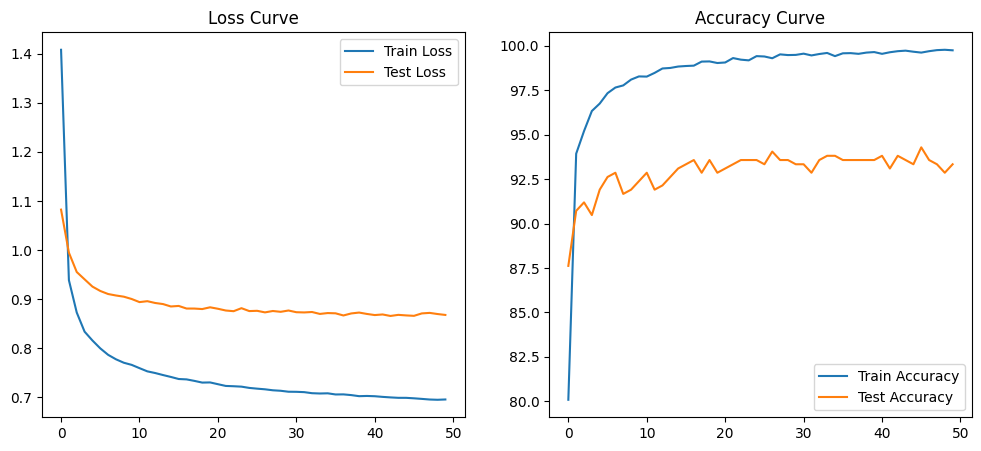

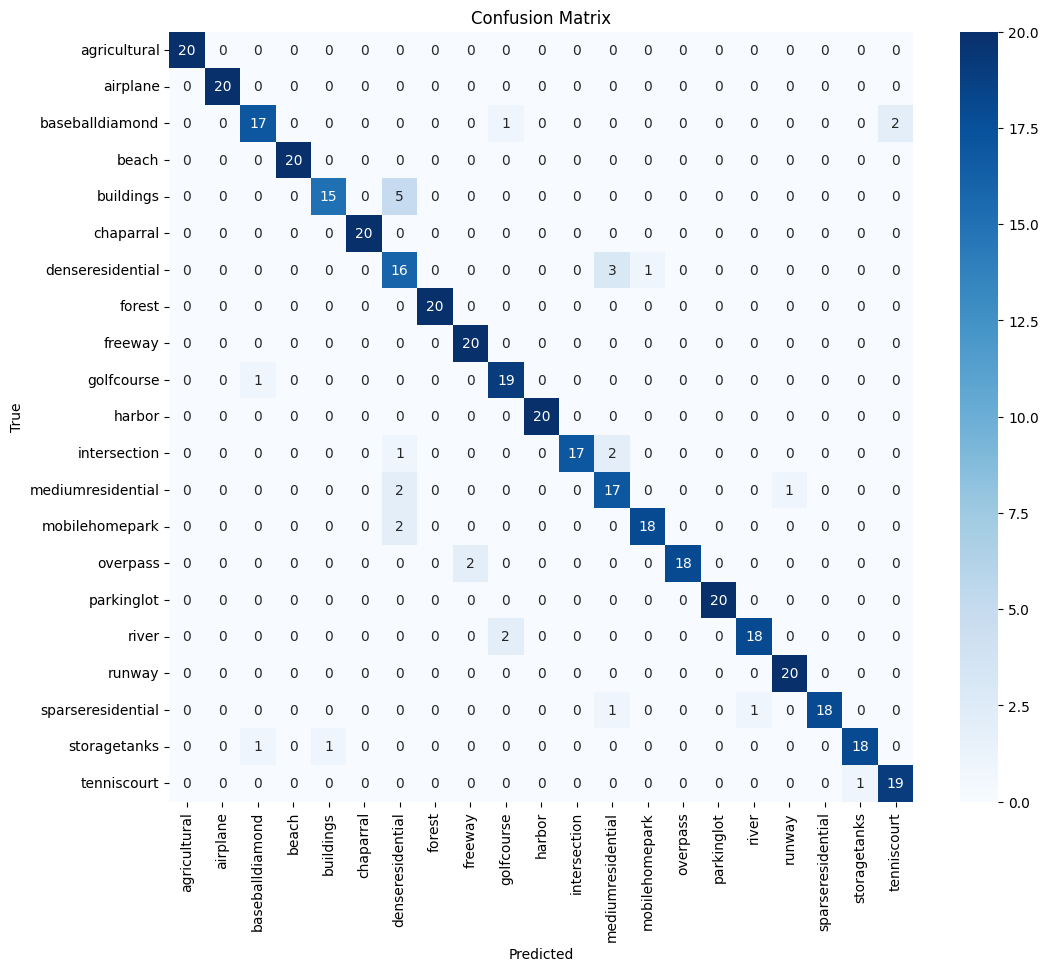


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       0.89      0.85      0.87        20
           3       1.00      1.00      1.00        20
           4       0.94      0.75      0.83        20
           5       1.00      1.00      1.00        20
           6       0.62      0.80      0.70        20
           7       1.00      1.00      1.00        20
           8       0.91      1.00      0.95        20
           9       0.86      0.95      0.90        20
          10       1.00      1.00      1.00        20
          11       1.00      0.85      0.92        20
          12       0.74      0.85      0.79        20
          13       0.95      0.90      0.92        20
          14       1.00      0.90      0.95        20
          15       1.00      1.00      1.00        20
          16       0.95      0.90      0.92        20
   

In [ ]:
batch_size = 200
train_loader_clean =  DataLoader(
    train_dataset_clean,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)


train_loader_aug6 = DataLoader(
    train_dataset_aug6,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)
# ----------------------------
num_classes = 21

# ----------------------------
# 2. Load Xception with default classifier
# ----------------------------
xception2 = timm.create_model(
    "legacy_xception",
    pretrained=True,
    num_classes=num_classes  # default classifier
)

# Optional: freeze feature extractor for transfer learning
for name, param in xception2.named_parameters():
    if "fc" not in name and "classifier" not in name:  # keep last layer trainable
        param.requires_grad = False





# ============================================================


experiments = [
    {"name": "Adagrad lr=0.01 smooth .1",        "epochs": 50, "lr": 0.01,  "label_smoothing": 0.1,  "optimizer_type": "adagrad"},
    {"name": "Adagrad lr=0.005 smooth .05",          "epochs": 50, "lr": 0.005, "label_smoothing": 0.05,  "optimizer_type": "adagrad"},
]

results = []



for exp in experiments:
    print(f"\nRunning: {exp['name']}")

    # Fresh model
    current_model = xception2

    # Train (silent)
    train_losses, train_accs, test_losses, test_accs, trained_model = train_model(
        current_model,
        train_loader_aug6,
        test_loader,
        classes,
        epochs=exp["epochs"],
        lr=exp["lr"],
        label_smoothing=exp["label_smoothing"],
        optimizer_type=exp["optimizer_type"]
    )

    # Store final epoch metrics ONLY
    results.append({
        "name": exp["name"],
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_accs": train_accs,
        "test_accs": test_accs,
        "model": trained_model,
        "final_train_acc": train_accs[-1],
        "final_test_acc": test_accs[-1],
        "final_train_loss": train_losses[-1],
        "final_test_loss": test_losses[-1],
    })


# ============================================================
#               PRINT FINAL METRICS OF ALL MODELS
# ============================================================

print("\n" + "="*80)
print("                  FINAL (LAST EPOCH) METRICS")
print("="*80)

for r in results:
    print(f"\n🔷 {r['name']}")
    print(f"   Final Train Accuracy : {r['final_train_acc']:.2f}%")
    print(f"   Final Test Accuracy  : {r['final_test_acc']:.2f}%")
    print(f"   Final Train Loss     : {r['final_train_loss']:.4f}")
    print(f"   Final Test Loss      : {r['final_test_loss']:.4f}")


# ============================================================
#         CHOOSE MODEL WITH HIGHEST FINAL TEST ACCURACY
# ============================================================

best_run = max(results, key=lambda r: r["final_test_acc"])

print("\n" + "="*80)
print(f" ⭐ MODEL SELECTED (Highest Final Test Accuracy): {best_run['name']}")
print(f" ⭐ Final Test Accuracy: {best_run['final_test_acc']:.2f}%")
print("="*80)

# Extract data
best_model = best_run["model"]
train_losses = best_run["train_losses"]
test_losses = best_run["test_losses"]
train_accs = best_run["train_accs"]
test_accs = best_run["test_accs"]

# ============================================================
#                  PLOT CURVES FOR SELECTED MODEL
# ============================================================

plot_curves(train_losses, test_losses, train_accs, test_accs)


# ============================================================
#            CONFUSION MATRIX FOR SELECTED MODEL
# ============================================================

show_confusion_matrix(best_model, test_loader, classes)


## 1-5-1


Running: Adagrad lr=0.01 smooth .1

Running: Adagrad lr=0.005 smooth .05

                  FINAL (LAST EPOCH) METRICS

🔷 Adagrad lr=0.01 smooth .1
   Final Train Accuracy : 87.02%
   Final Test Accuracy  : 87.14%
   Final Train Loss     : 1.0906
   Final Test Loss      : 1.0790

🔷 Adagrad lr=0.005 smooth .05
   Final Train Accuracy : 84.35%
   Final Test Accuracy  : 86.19%
   Final Train Loss     : 0.9930
   Final Test Loss      : 0.9833

 ⭐ MODEL SELECTED (Highest Final Test Accuracy): Adagrad lr=0.01 smooth .1
 ⭐ Final Test Accuracy: 87.14%


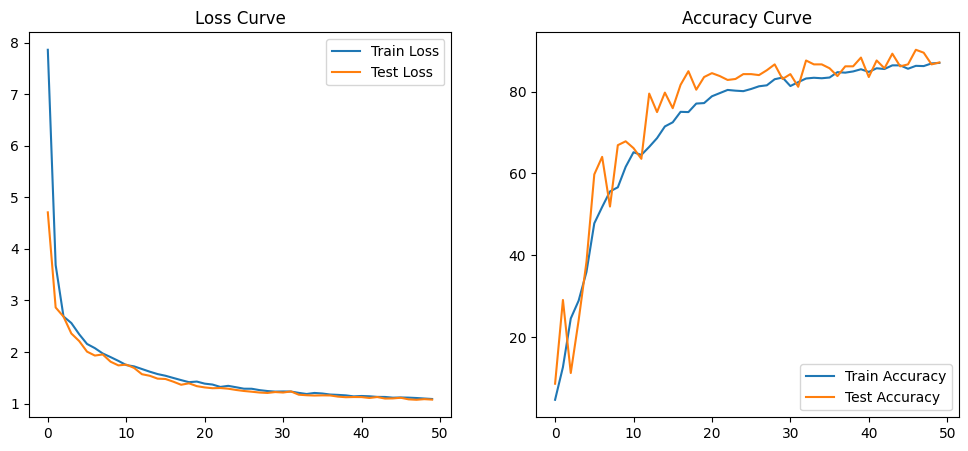

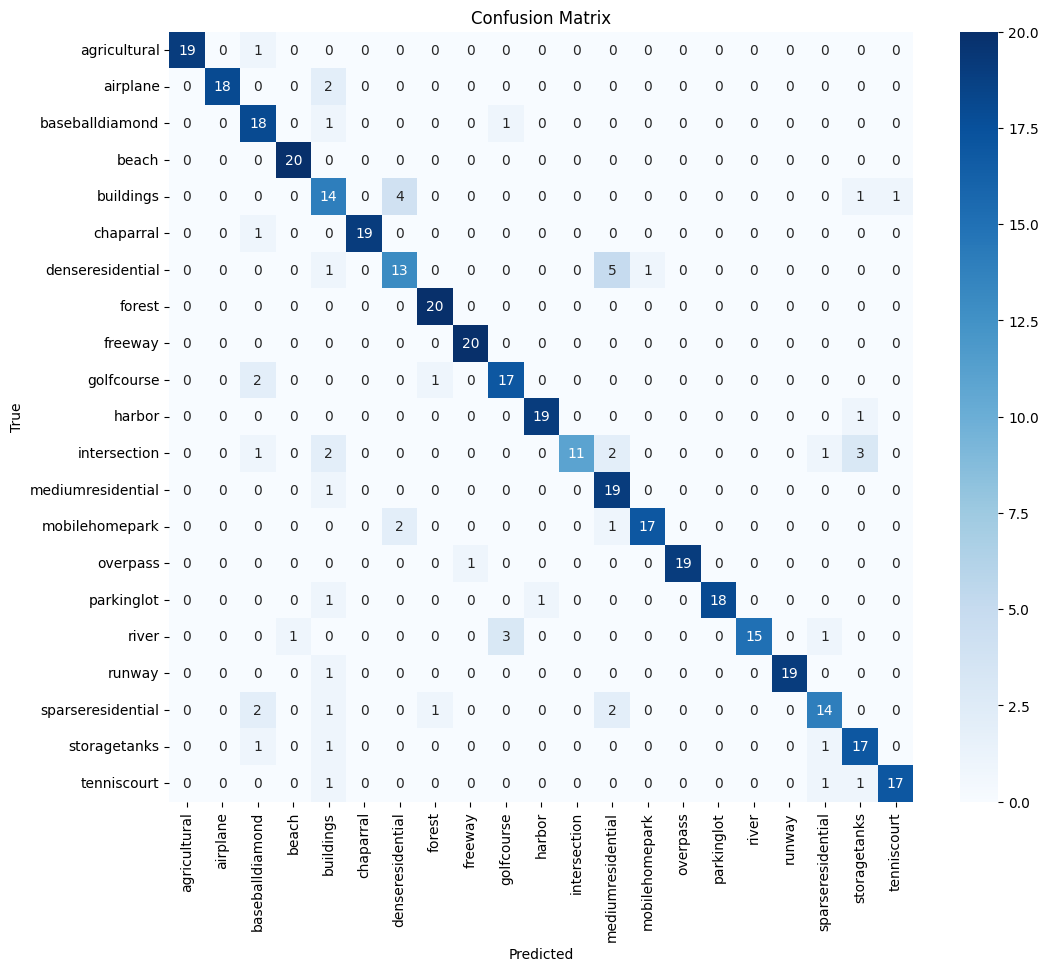


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        20
           1       1.00      0.90      0.95        20
           2       0.69      0.90      0.78        20
           3       0.95      1.00      0.98        20
           4       0.54      0.70      0.61        20
           5       1.00      0.95      0.97        20
           6       0.68      0.65      0.67        20
           7       0.91      1.00      0.95        20
           8       0.95      1.00      0.98        20
           9       0.81      0.85      0.83        20
          10       0.95      0.95      0.95        20
          11       1.00      0.55      0.71        20
          12       0.66      0.95      0.78        20
          13       0.94      0.85      0.89        20
          14       1.00      0.95      0.97        20
          15       1.00      0.90      0.95        20
          16       1.00      0.75      0.86        20
   

In [ ]:
batch_size = 200
train_loader_clean =  DataLoader(
    train_dataset_clean,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)


train_loader_aug6 = DataLoader(
    train_dataset_aug6,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

# ============================================================
#               RUN 3 EXPERIMENTS & SELECT BEST MODEL
# ============================================================

experiments = [
    {"name": "Adagrad lr=0.01 smooth .1",        "epochs": 50, "lr": 0.01,  "label_smoothing": 0.1,  "optimizer_type": "adagrad"},
    {"name": "Adagrad lr=0.005 smooth .05",          "epochs": 50, "lr": 0.005, "label_smoothing": 0.05,  "optimizer_type": "adagrad"},
]

results = []



for exp in experiments:
    print(f"\nRunning: {exp['name']}")

    # Fresh model
    current_model = SequentialClassifier(
        feature_extractor=xception,
        num_classes=len(classes)
    )

    # Train (silent)
    train_losses, train_accs, test_losses, test_accs, trained_model = train_model(
        current_model,
        train_loader_clean,
        test_loader,
        classes,
        epochs=exp["epochs"],
        lr=exp["lr"],
        label_smoothing=exp["label_smoothing"],
        optimizer_type=exp["optimizer_type"]
    )

    # Store final epoch metrics ONLY
    results.append({
        "name": exp["name"],
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_accs": train_accs,
        "test_accs": test_accs,
        "model": trained_model,
        "final_train_acc": train_accs[-1],
        "final_test_acc": test_accs[-1],
        "final_train_loss": train_losses[-1],
        "final_test_loss": test_losses[-1],
    })


# ============================================================
#               PRINT FINAL METRICS OF ALL MODELS
# ============================================================

print("\n" + "="*80)
print("                  FINAL (LAST EPOCH) METRICS")
print("="*80)

for r in results:
    print(f"\n🔷 {r['name']}")
    print(f"   Final Train Accuracy : {r['final_train_acc']:.2f}%")
    print(f"   Final Test Accuracy  : {r['final_test_acc']:.2f}%")
    print(f"   Final Train Loss     : {r['final_train_loss']:.4f}")
    print(f"   Final Test Loss      : {r['final_test_loss']:.4f}")


# ============================================================
#         CHOOSE MODEL WITH HIGHEST FINAL TEST ACCURACY
# ============================================================

best_run = max(results, key=lambda r: r["final_test_acc"])

print("\n" + "="*80)
print(f" ⭐ MODEL SELECTED (Highest Final Test Accuracy): {best_run['name']}")
print(f" ⭐ Final Test Accuracy: {best_run['final_test_acc']:.2f}%")
print("="*80)

# Extract data
best_model = best_run["model"]
train_losses = best_run["train_losses"]
test_losses = best_run["test_losses"]
train_accs = best_run["train_accs"]
test_accs = best_run["test_accs"]

# ============================================================
#                  PLOT CURVES FOR SELECTED MODEL
# ============================================================

plot_curves(train_losses, test_losses, train_accs, test_accs)

# ============================================================
#            CONFUSION MATRIX FOR SELECTED MODEL
# ============================================================


show_confusion_matrix(best_model, test_loader, classes)

## 1-5-2


Running: Adam lr=0.01 smooth .1

Running: Adam lr=0.005 smooth .1

                  FINAL (LAST EPOCH) METRICS

🔷 Adam lr=0.01 smooth .1
   Final Train Accuracy : 85.58%
   Final Test Accuracy  : 86.67%
   Final Train Loss     : 1.2026
   Final Test Loss      : 1.1204

🔷 Adam lr=0.005 smooth .1
   Final Train Accuracy : 88.33%
   Final Test Accuracy  : 92.38%
   Final Train Loss     : 1.0323
   Final Test Loss      : 0.9399

 ⭐ MODEL SELECTED (Highest Final Test Accuracy): Adam lr=0.005 smooth .1
 ⭐ Final Test Accuracy: 92.38%


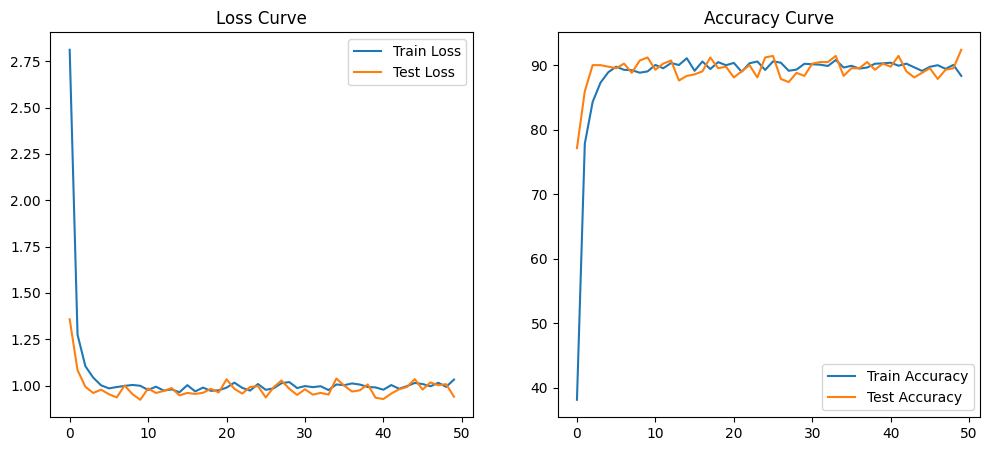

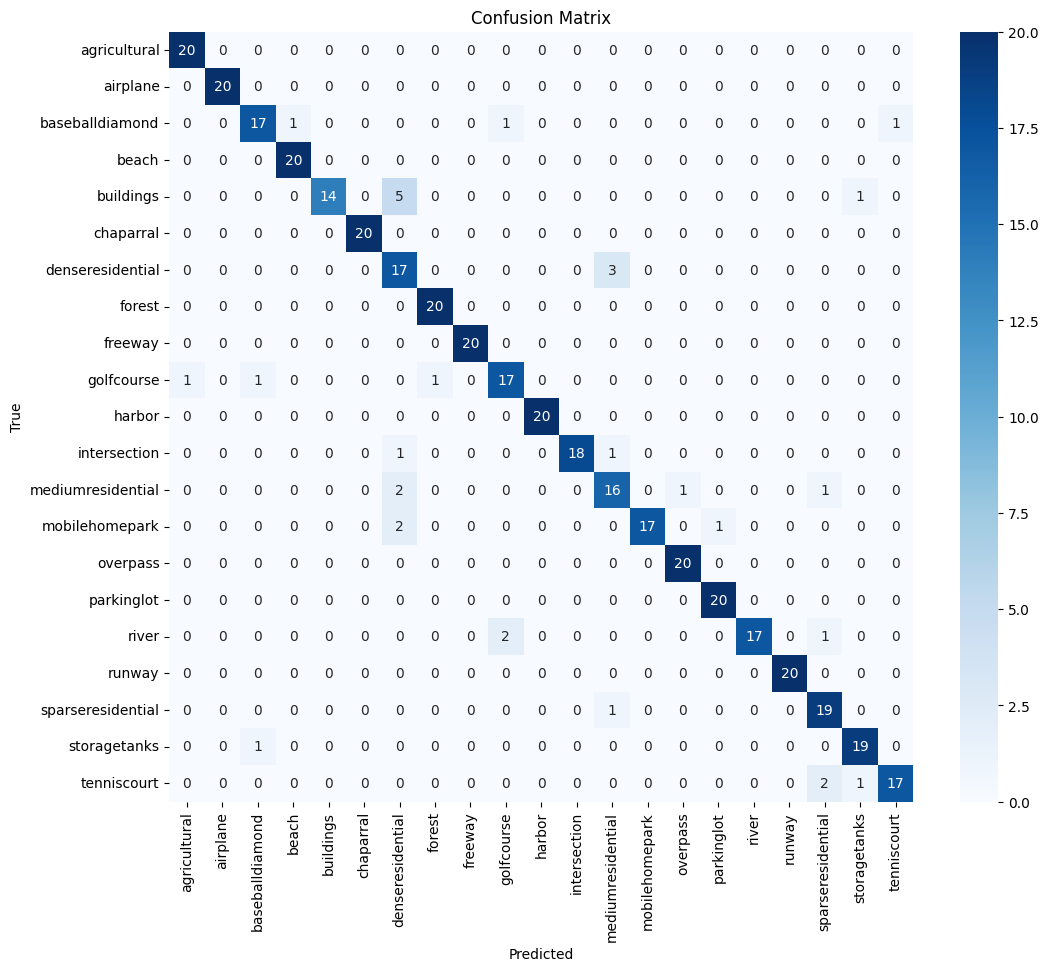


Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      1.00      1.00        20
           2       0.89      0.85      0.87        20
           3       0.95      1.00      0.98        20
           4       1.00      0.70      0.82        20
           5       1.00      1.00      1.00        20
           6       0.63      0.85      0.72        20
           7       0.95      1.00      0.98        20
           8       1.00      1.00      1.00        20
           9       0.85      0.85      0.85        20
          10       1.00      1.00      1.00        20
          11       1.00      0.90      0.95        20
          12       0.76      0.80      0.78        20
          13       1.00      0.85      0.92        20
          14       0.95      1.00      0.98        20
          15       0.95      1.00      0.98        20
          16       1.00      0.85      0.92        20
   

In [ ]:
batch_size = 200
train_loader_clean =  DataLoader(
    train_dataset_clean,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)


train_loader_aug6 = DataLoader(
    train_dataset_aug6,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)
# ============================================================
#               RUN 3 EXPERIMENTS & SELECT BEST MODEL
# ============================================================

experiments = [
    {"name": "Adam lr=0.01 smooth .1",        "epochs": 50, "lr": 0.01,  "label_smoothing": 0.1,  "optimizer_type": "adam"},
    {"name": "Adam lr=0.005 smooth .1",          "epochs": 50, "lr": 0.005, "label_smoothing": 0.1,  "optimizer_type": "adam"},
]

results = []



for exp in experiments:
    print(f"\nRunning: {exp['name']}")

    # Fresh model
    current_model = SequentialClassifier(
        feature_extractor=xception,
        num_classes=len(classes)
    )

    # Train (silent)
    train_losses, train_accs, test_losses, test_accs, trained_model = train_model(
        current_model,
        train_loader_aug6,
        test_loader,
        classes,
        epochs=exp["epochs"],
        lr=exp["lr"],
        label_smoothing=exp["label_smoothing"],
        optimizer_type=exp["optimizer_type"]
    )

    # Store final epoch metrics ONLY
    results.append({
        "name": exp["name"],
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_accs": train_accs,
        "test_accs": test_accs,
        "model": trained_model,
        "final_train_acc": train_accs[-1],
        "final_test_acc": test_accs[-1],
        "final_train_loss": train_losses[-1],
        "final_test_loss": test_losses[-1],
    })


# ============================================================
#               PRINT FINAL METRICS OF ALL MODELS
# ============================================================

print("\n" + "="*80)
print("                  FINAL (LAST EPOCH) METRICS")
print("="*80)

for r in results:
    print(f"\n🔷 {r['name']}")
    print(f"   Final Train Accuracy : {r['final_train_acc']:.2f}%")
    print(f"   Final Test Accuracy  : {r['final_test_acc']:.2f}%")
    print(f"   Final Train Loss     : {r['final_train_loss']:.4f}")
    print(f"   Final Test Loss      : {r['final_test_loss']:.4f}")


# ============================================================
#         CHOOSE MODEL WITH HIGHEST FINAL TEST ACCURACY
# ============================================================

best_run = max(results, key=lambda r: r["final_test_acc"])

print("\n" + "="*80)
print(f" ⭐ MODEL SELECTED (Highest Final Test Accuracy): {best_run['name']}")
print(f" ⭐ Final Test Accuracy: {best_run['final_test_acc']:.2f}%")
print("="*80)

# Extract data
best_model = best_run["model"]
train_losses = best_run["train_losses"]
test_losses = best_run["test_losses"]
train_accs = best_run["train_accs"]
test_accs = best_run["test_accs"]

# ============================================================
#                  PLOT CURVES FOR SELECTED MODEL
# ============================================================

plot_curves(train_losses, test_losses, train_accs, test_accs)

# ============================================================
#            CONFUSION MATRIX FOR SELECTED MODEL
# ============================================================

show_confusion_matrix(best_model, test_loader, classes)

## 1-5-3


Running: Adam lr=0.001 smooth .1

Running: Adam lr=0.0005 smooth .1

                  FINAL (LAST EPOCH) METRICS

🔷 Adam lr=0.001 smooth .1
   Final Train Accuracy : 93.05%
   Final Test Accuracy  : 92.38%
   Final Train Loss     : 0.8992
   Final Test Loss      : 0.8900

🔷 Adam lr=0.0005 smooth .1
   Final Train Accuracy : 93.46%
   Final Test Accuracy  : 91.43%
   Final Train Loss     : 0.6098
   Final Test Loss      : 0.6385

 ⭐ MODEL SELECTED (Highest Final Test Accuracy): Adam lr=0.001 smooth .1
 ⭐ Final Test Accuracy: 92.38%


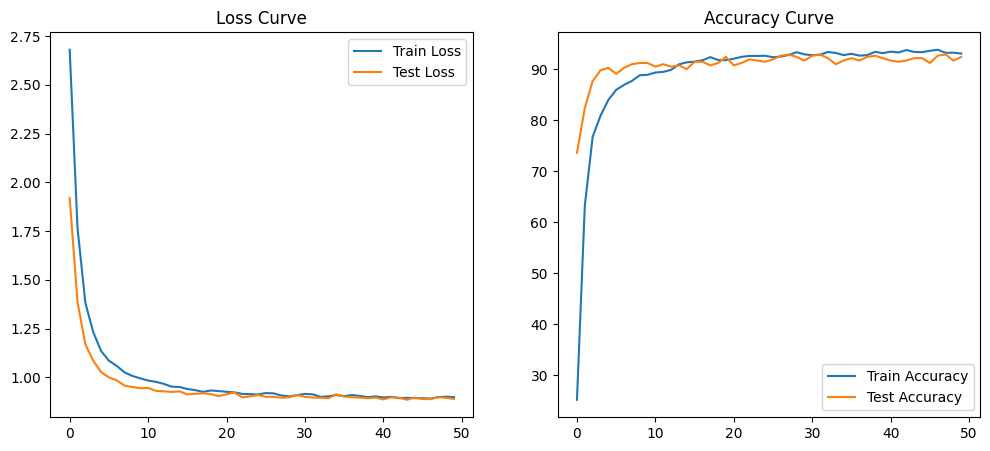

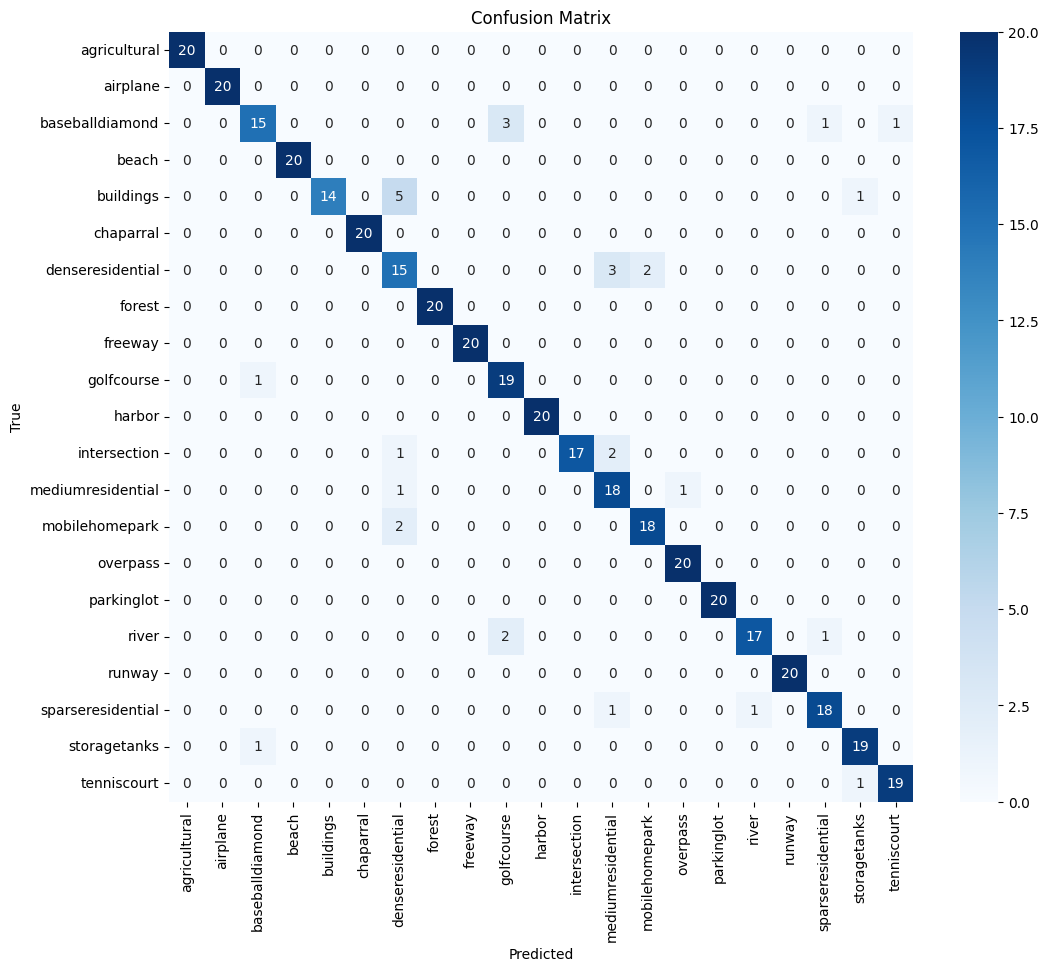


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        20
           2       0.88      0.75      0.81        20
           3       1.00      1.00      1.00        20
           4       1.00      0.70      0.82        20
           5       1.00      1.00      1.00        20
           6       0.62      0.75      0.68        20
           7       1.00      1.00      1.00        20
           8       1.00      1.00      1.00        20
           9       0.79      0.95      0.86        20
          10       1.00      1.00      1.00        20
          11       1.00      0.85      0.92        20
          12       0.75      0.90      0.82        20
          13       0.90      0.90      0.90        20
          14       0.95      1.00      0.98        20
          15       1.00      1.00      1.00        20
          16       0.94      0.85      0.89        20
   

In [9]:
batch_size = 200
train_loader_clean =  DataLoader(
    train_dataset_clean,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)


train_loader_aug6 = DataLoader(
    train_dataset_aug6,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

xception3 = timm.create_model(
    "legacy_xception",
    pretrained=True,
    num_classes=0,
    global_pool='avg'
)

# 2. Freeze EVERYTHING first
for p in xception3.parameters():
    p.requires_grad = False

# 3. Unfreeze the last 10 parameter tensors
# We convert the generator to a list so we can slice it
params = list(xception.parameters())

# Slice the last 10 and enable gradients
for p in params[-10:]:
    p.requires_grad = True


# ============================================================
#               RUN 3 EXPERIMENTS & SELECT BEST MODEL
# ============================================================

experiments = [
    {"name": "Adam lr=0.001 smooth .1",        "epochs": 50, "lr": 0.001,  "label_smoothing": 0.1,  "optimizer_type": "adam"},
    {"name": "Adam lr=0.0005 smooth .005",          "epochs": 50, "lr": 0.0005, "label_smoothing": 0.05,  "optimizer_type": "adam"},

]

results = []



for exp in experiments:
    print(f"\nRunning: {exp['name']}")

    # Fresh model
    current_model = SequentialClassifier(
        feature_extractor=xception3,
        num_classes=len(classes)
    )

    # Train (silent)
    train_losses, train_accs, test_losses, test_accs, trained_model = train_model(
        current_model,
        train_loader_aug6,
        test_loader,
        classes,
        epochs=exp["epochs"],
        lr=exp["lr"],
        label_smoothing=exp["label_smoothing"],
        optimizer_type=exp["optimizer_type"]
    )

    # Store final epoch metrics ONLY
    results.append({
        "name": exp["name"],
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_accs": train_accs,
        "test_accs": test_accs,
        "model": trained_model,
        "final_train_acc": train_accs[-1],
        "final_test_acc": test_accs[-1],
        "final_train_loss": train_losses[-1],
        "final_test_loss": test_losses[-1],
    })


# ============================================================
#               PRINT FINAL METRICS OF ALL MODELS
# ============================================================

print("\n" + "="*80)
print("                  FINAL (LAST EPOCH) METRICS")
print("="*80)

for r in results:
    print(f"\n🔷 {r['name']}")
    print(f"   Final Train Accuracy : {r['final_train_acc']:.2f}%")
    print(f"   Final Test Accuracy  : {r['final_test_acc']:.2f}%")
    print(f"   Final Train Loss     : {r['final_train_loss']:.4f}")
    print(f"   Final Test Loss      : {r['final_test_loss']:.4f}")


# ============================================================
#         CHOOSE MODEL WITH HIGHEST FINAL TEST ACCURACY
# ============================================================

best_run = max(results, key=lambda r: r["final_test_acc"])

print("\n" + "="*80)
print(f" ⭐ MODEL SELECTED (Highest Final Test Accuracy): {best_run['name']}")
print(f" ⭐ Final Test Accuracy: {best_run['final_test_acc']:.2f}%")
print("="*80)

# Extract data
best_model = best_run["model"]
train_losses = best_run["train_losses"]
test_losses = best_run["test_losses"]
train_accs = best_run["train_accs"]
test_accs = best_run["test_accs"]

# ============================================================
#                  PLOT CURVES FOR SELECTED MODEL
# ============================================================

plot_curves(train_losses, test_losses, train_accs, test_accs)

# ============================================================
#            CONFUSION MATRIX FOR SELECTED MODEL
# ============================================================

show_confusion_matrix(best_model, test_loader, classes)